# Support Vector Machines (SVM): Kernel Analysis

## GitHub Repository
https://github.com/nishanth1914/svm-kernel-analysis

## Aim of the Tutorial

This tutorial explores how different kernel functions (Linear, Polynomial, and RBF) affect the performance and decision boundaries of Support Vector Machines.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import svm, datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [2]:
iris = datasets.load_iris()
X = iris.data[:, :2]
y = iris.target

## Dataset

The Iris dataset is used in this tutorial. It is a well-known dataset for classification tasks and contains three classes of flowers.

Only two features are used to allow visualisation of decision boundaries.

In [3]:
models = [
    svm.SVC(kernel='linear'),
    svm.SVC(kernel='poly', degree=3),
    svm.SVC(kernel='rbf')
]

titles = ['Linear Kernel', 'Polynomial Kernel', 'RBF Kernel']

for model in models:
    model.fit(X, y)

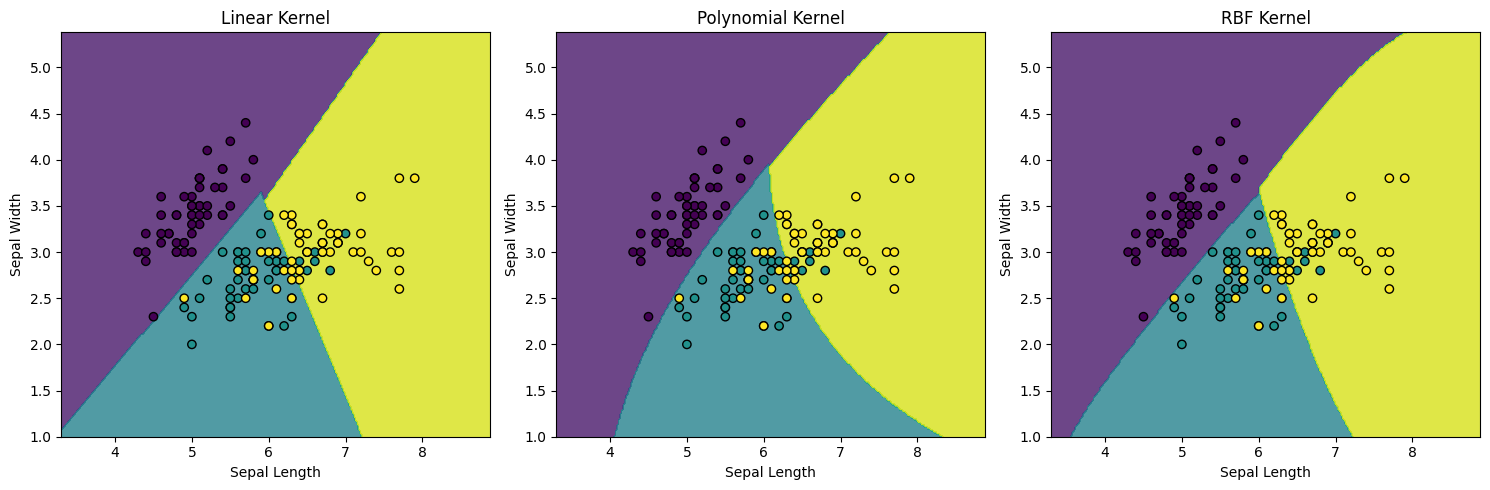

In [6]:
# Plot decision boundaries
fig, axes = plt.subplots(1, 3, figsize=(15,5))

for ax, model, title in zip(axes, models, titles):
    h = 0.02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    ax.contourf(xx, yy, Z, alpha=0.8)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k')
    ax.set_title(title)
    ax.set_xlabel('Sepal Length')
    ax.set_ylabel('Sepal Width')

plt.tight_layout()
plt.show()

## Analysis of Results

- The Linear kernel produces straight decision boundaries.
- The Polynomial kernel creates curved boundaries.
- The RBF kernel produces highly flexible boundaries and separates the data better.

This shows that kernel choice significantly affects model performance.

## Accuracy Comparison

We now evaluate how well each kernel performs on unseen data.

In [7]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [8]:
# Calculate accuracy
accuracies = []

for model, title in zip(models, titles):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    accuracies.append(acc)
    print(f"{title} Accuracy: {acc:.2f}")

Linear Kernel Accuracy: 0.80
Polynomial Kernel Accuracy: 0.73
RBF Kernel Accuracy: 0.80


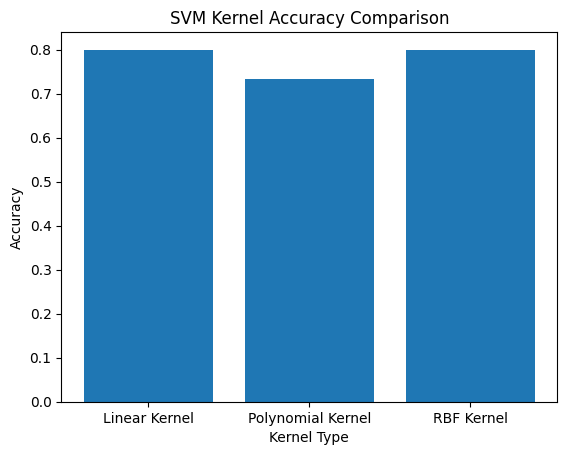

In [9]:
# Plot accuracy comparison
plt.figure()
plt.bar(titles, accuracies)
plt.xlabel("Kernel Type")
plt.ylabel("Accuracy")
plt.title("SVM Kernel Accuracy Comparison")
plt.show()

## Conclusion

This tutorial demonstrated how different kernel functions affect SVM performance.

- Linear kernel works well for simple data
- Polynomial kernel captures more complex patterns
- RBF kernel performs best for non-linear data

Choosing the correct kernel is essential for achieving high accuracy.